<a href="https://colab.research.google.com/github/chiamakachijioke/urban-mobility-optimisation/blob/main/notebooks/05_Bellman%E2%80%93Ford.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bellman–Ford Shortest Path Algorithm

This notebook implements the Bellman–Ford algorithm from scratch.

Bellman–Ford finds the shortest paths from one starting node to the other reachable nodes in a weighted graph.

Unlike Dijkstra's algorithm, Bellman–Ford can work with negative edge weights.

It can also detect a reachable negative-weight cycle.
---
---
---
---


## Why Bellman–Ford is needed

Dijkstra's algorithm assumes that every edge weight is non-negative.

Bellman–Ford does not make this assumption. It can correctly process graphs that contain negative edge weights.

However, if a reachable negative cycle exists, there is no fixed shortest path because repeatedly travelling around the cycle keeps reducing the total cost.


For example:

    1 → 2 has weight -2

This could represent a mathematical benefit, discount, credit or reduction.

It does not usually represent physical distance, because physical distance cannot be negative.

**What is a negative cycle?**

Suppose:

    1 → 2 = -2
    2 → 1 = -3

The total cycle cost is:

    -2 + -3 = -5

Every time we travel around it, the cost falls by another 5:

    First time:  -5
    Second time: -10
    Third time:  -15

Therefore, there is no final shortest cost.

---
---
---
---
---

# **Import the libraries**

In [1]:
import math

import matplotlib.pyplot as plt
import networkx as nx

## Note:
Bellman–Ford does not require heapq.

That is because it does not use a priority queue like Dijkstra and A*.

## **Create a directed test graph**

## Test graph

This example uses a directed graph.

An edge from node 0 to node 1 does not automatically mean that an edge exists from node 1 back to node 0.

The graph contains one negative edge but does not contain a negative cycle.

In [2]:
graph = {
    0: {
        1: 4,
        2: 5
    },

    1: {
        2: -2,
        3: 6
    },

    2: {
        3: 3
    },

    3: {
        4: 2
    },

    4: {}
}

## Interpreting the graph:

    0 → 1 has weight 4
    0 → 2 has weight 5
    1 → 2 has weight -2
    1 → 3 has weight 6
    2 → 3 has weight 3
    3 → 4 has weight 2

The important negative edge is:

    1 → 2 = -2

# **Inspect the adjacency list**

In [3]:
for node, neighbours in graph.items():
    print(f"Node {node}: {neighbours}")

Node 0: {1: 4, 2: 5}
Node 1: {2: -2, 3: 6}
Node 2: {3: 3}
Node 3: {4: 2}
Node 4: {}


# **Create an edge-list function**

Bellman–Ford repeatedly examines every edge.

My graph is currently stored as an adjacency list, so I need to extract all edges

In [4]:
def create_edge_list(graph_data):
    edge_list = []

    for start_node, neighbours in graph_data.items():
        for end_node, edge_weight in neighbours.items():
            edge_list.append(
                (
                    start_node,
                    end_node,
                    edge_weight
                )
            )

    return edge_list

In [5]:
# Testing:

edges = create_edge_list(graph)

print("Edges:")

for edge in edges:
    print(edge)

Edges:
(0, 1, 4)
(0, 2, 5)
(1, 2, -2)
(1, 3, 6)
(2, 3, 3)
(3, 4, 2)


Each tuple has this form:

    (start node, end node, edge weight)

# **How Bellman–Ford works**

## How Bellman–Ford works

Bellman–Ford first gives the starting node a distance of 0 and every other node a distance of infinity.

It then examines every edge and checks whether using that edge creates a shorter route.

This relaxation process is repeated at most |V| - 1 times, where |V| is the number of nodes.

After these repetitions, the algorithm examines all edges once more.

If another improvement is still possible, a reachable negative cycle exists.

For five nodes:

    |V| = 5

So Bellman–Ford performs at most:

    |V| - 1 = 4

full relaxation rounds.


# **Why repeat |V| - 1 times?**

## Why the edges are relaxed |V| - 1 times

A shortest path without repeated nodes can contain at most |V| - 1 edges.

With five nodes, the longest possible simple shortest path contains at most four edges.

Each full relaxation round allows improved distance information to move farther through the graph.

For example:

Round 1 may improve nodes close to the start.

Round 2 may pass those improvements farther through the network.

Later rounds allow the information to continue propagating.

# **Create the Bellman–Ford function**

In [6]:
# Create the Bellman–Ford function

def bellman_ford(
    graph_data,
    start_node
):
    if start_node not in graph_data:
        raise ValueError(
            f"Start node {start_node} does not exist."
        )

    distances = {
        node: math.inf
        for node in graph_data
    }

    predecessors = {
        node: None
        for node in graph_data
    }

    distances[start_node] = 0

    edges = create_edge_list(graph_data)

    number_of_nodes = len(graph_data)

    completed_iterations = 0

    for iteration in range(number_of_nodes - 1):
        distance_updated = False

        for (
            current_node,
            neighbour,
            edge_weight
        ) in edges:

            if distances[current_node] == math.inf:
                continue

            new_distance = (
                distances[current_node]
                + edge_weight
            )

            if new_distance < distances[neighbour]:
                distances[neighbour] = new_distance
                predecessors[neighbour] = current_node

                distance_updated = True

        completed_iterations += 1

        if not distance_updated:
            break

    negative_cycle_found = False

    for (
        current_node,
        neighbour,
        edge_weight
    ) in edges:

        if distances[current_node] == math.inf:
            continue

        new_distance = (
            distances[current_node]
            + edge_weight
        )

        if new_distance < distances[neighbour]:
            negative_cycle_found = True
            break

    return (
        distances,
        predecessors,
        negative_cycle_found,
        completed_iterations
    )

# **Run Bellman–Ford**

In [7]:
# Run Bellman–Ford

start_node = 0

(
    distances,
    predecessors,
    negative_cycle_found,
    completed_iterations
) = bellman_ford(
    graph,
    start_node
)

In [10]:
# Printing:

print("Start node:", start_node)
print("Distances:", distances)
print("Predecessors:", predecessors)
print(
    "Negative cycle found:",
    negative_cycle_found
)
print(
    "Completed iterations:",
    completed_iterations
)

Start node: 0
Distances: {0: 0, 1: 4, 2: 2, 3: 5, 4: 7}
Predecessors: {0: None, 1: 0, 2: 1, 3: 2, 4: 3}
Negative cycle found: False
Completed iterations: 2


# **Reconstruct a path**

In [8]:
# Same used in Dijkstra notebook

def reconstruct_path(
    predecessors,
    start_node,
    destination_node
):
    path = []
    current_node = destination_node

    while current_node is not None:
        path.append(current_node)

        if current_node == start_node:
            break

        current_node = predecessors[current_node]

    path.reverse()

    if not path or path[0] != start_node:
        return None

    return path

In [9]:
# Testing:

destination_node = 4

shortest_path = reconstruct_path(
    predecessors,
    start_node,
    destination_node
)

print("Shortest path:", shortest_path)
print(
    "Shortest path cost:",
    distances[destination_node]
)

Shortest path: [0, 1, 2, 3, 4]
Shortest path cost: 7


The main difference is:

Dijkstra relaxes edges from the currently selected closest node.
A* relaxes edges from the most promising node.
Bellman–Ford repeatedly relaxes every edge.

# **Create a clean Bellman–Ford wrapper**

In [11]:
def find_bellman_ford_path(
    graph_data,
    start_node,
    destination_node
):
    if destination_node not in graph_data:
        raise ValueError(
            f"Destination node {destination_node} does not exist."
        )

    (
        distances,
        predecessors,
        negative_cycle_found,
        completed_iterations
    ) = bellman_ford(
        graph_data,
        start_node
    )

    if negative_cycle_found:
        return {
            "path": None,
            "cost": None,
            "negative_cycle": True,
            "iterations": completed_iterations
        }

    path = reconstruct_path(
        predecessors,
        start_node,
        destination_node
    )

    if path is None:
        return {
            "path": None,
            "cost": math.inf,
            "negative_cycle": False,
            "iterations": completed_iterations
        }

    return {
        "path": path,
        "cost": round(
            distances[destination_node],
            2
        ),
        "negative_cycle": False,
        "iterations": completed_iterations
    }

In [12]:
# Testing:

result = find_bellman_ford_path(
    graph,
    0,
    4
)

print("Path:", result["path"])
print("Cost:", result["cost"])
print(
    "Negative cycle:",
    result["negative_cycle"]
)
print(
    "Iterations:",
    result["iterations"]
)

Path: [0, 1, 2, 3, 4]
Cost: 7
Negative cycle: False
Iterations: 2


# **Test several destinations**

In [13]:
for destination in graph:
    result = find_bellman_ford_path(
        graph,
        0,
        destination
    )

    print(f"0 → {destination}")
    print("Path:", result["path"])
    print("Cost:", result["cost"])
    print("-" * 30)

0 → 0
Path: [0]
Cost: 0
------------------------------
0 → 1
Path: [0, 1]
Cost: 4
------------------------------
0 → 2
Path: [0, 1, 2]
Cost: 2
------------------------------
0 → 3
Path: [0, 1, 2, 3]
Cost: 5
------------------------------
0 → 4
Path: [0, 1, 2, 3, 4]
Cost: 7
------------------------------


# **Build a NetworkX directed graph**

In [14]:
transport_graph = nx.DiGraph()

for node in graph:
    transport_graph.add_node(node)

for current_node, neighbours in graph.items():
    for neighbour, edge_weight in neighbours.items():
        transport_graph.add_edge(
            current_node,
            neighbour,
            weight=edge_weight
        )

##Note:
I use:

    nx.DiGraph()

rather than:

    nx.Graph()

because the edges are directed.

# **Create positions for visualisation**

In [15]:
positions = {
    0: (0, 1),
    1: (1, 2),
    2: (2, 1),
    3: (3, 2),
    4: (4, 1)
}

# **Visualise the graph and shortest path**

In [16]:
def plot_bellman_ford_path(
    network,
    positions,
    path
):
    path_edges = list(
        zip(
            path[:-1],
            path[1:]
        )
    )

    plt.figure(figsize=(10, 6))

    nx.draw(
        network,
        pos=positions,
        with_labels=True,
        node_size=1000,
        font_size=11,
        arrows=True
    )

    nx.draw_networkx_edges(
        network,
        pos=positions,
        edgelist=path_edges,
        width=4,
        arrows=True
    )

    edge_labels = nx.get_edge_attributes(
        network,
        "weight"
    )

    nx.draw_networkx_edge_labels(
        network,
        pos=positions,
        edge_labels=edge_labels,
        font_size=10
    )

    plt.title(
        f"Bellman–Ford Shortest Path: {path}"
    )

    plt.show()

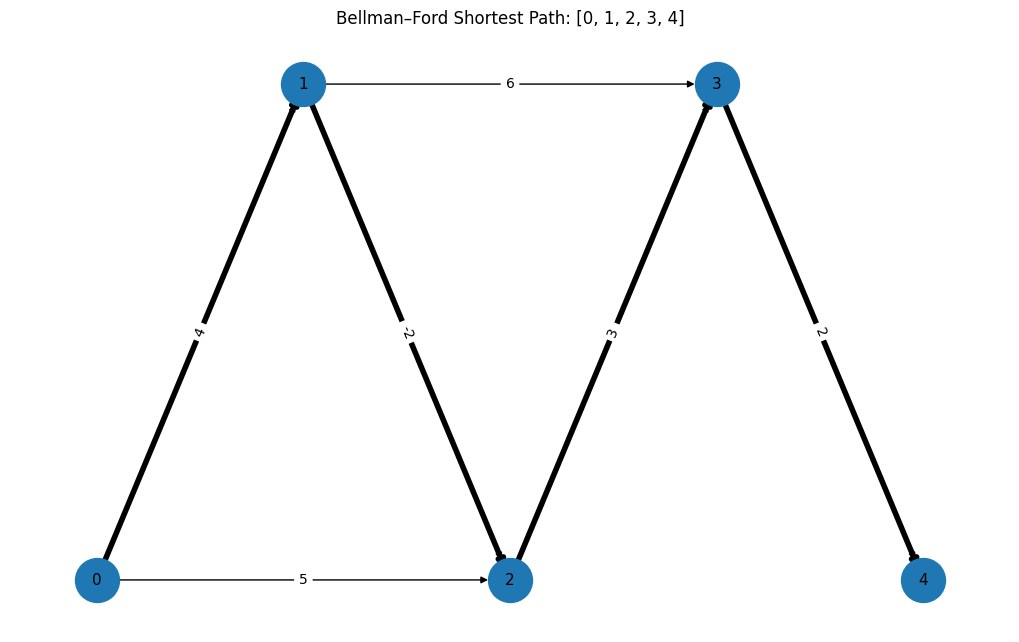

In [17]:
result = find_bellman_ford_path(
    graph,
    0,
    4
)

plot_bellman_ford_path(
    transport_graph,
    positions,
    result["path"]
)

# **Verify using NetworkX**

In [18]:
networkx_path = nx.bellman_ford_path(
    transport_graph,
    source=0,
    target=4,
    weight="weight"
)

networkx_cost = nx.bellman_ford_path_length(
    transport_graph,
    source=0,
    target=4,
    weight="weight"
)

print(
    "NetworkX path:",
    networkx_path
)

print(
    "NetworkX cost:",
    networkx_cost
)

NetworkX path: [0, 1, 2, 3, 4]
NetworkX cost: 7


# **Test negative-cycle detection**

I use a separate graph so I do not alter the main example

In [19]:
negative_cycle_graph = {
    0: {
        1: 4
    },

    1: {
        2: -2
    },

    2: {
        1: -3,
        3: 2
    },

    3: {}
}

## Compare Dijkstra and Bellman–Ford


| Feature                                 | Dijkstra            | Bellman–Ford                |
| --------------------------------------- | ------------------- | --------------------------- |
| Finds shortest paths                    | Yes                 | Yes                         |
| Allows negative edges                   | No                  | Yes                         |
| Detects negative cycles                 | No                  | Yes                         |
| Uses a priority queue                   | Usually             | No                          |
| Main approach                           | Select closest node | Repeatedly relax every edge |
| Generally faster                        | Yes                 | No                          |
| Best choice for positive road distances | Usually             | Works, but slower           |


The main idea is:

Use Dijkstra when all weights are non-negative and speed matters.

Use Bellman–Ford when negative weights may exist or when negative-cycle detection is required.

# **Save reusable Bellman–Ford functions**

In [22]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [23]:
%%writefile -a /content/drive/MyDrive/PhD_Optimisation_Code/modules/shortest_path_algorithms.py


# BELLMAN–FORD SUPPORT FUNCTION

def create_edge_list(graph_data):
    """
    Convert an adjacency-list graph into a list of directed
    edges in the form:
    (start_node, end_node, edge_weight).
    """

    edge_list = []

    for start_node, neighbours in graph_data.items():
        for end_node, edge_weight in neighbours.items():
            edge_list.append(
                (
                    start_node,
                    end_node,
                    edge_weight
                )
            )

    return edge_list


# BELLMAN–FORD ALGORITHM

def bellman_ford(
    graph_data,
    start_node
):
    """
    Calculate shortest distances from one starting node using
    Bellman–Ford.

    The algorithm allows negative edge weights and detects
    reachable negative-weight cycles.
    """

    if start_node not in graph_data:
        raise ValueError(
            f"Start node {start_node} does not exist."
        )

    distances = {
        node: math.inf
        for node in graph_data
    }

    predecessors = {
        node: None
        for node in graph_data
    }

    distances[start_node] = 0

    edges = create_edge_list(graph_data)

    number_of_nodes = len(graph_data)

    completed_iterations = 0

    for iteration in range(number_of_nodes - 1):
        distance_updated = False

        for (
            current_node,
            neighbour,
            edge_weight
        ) in edges:

            if distances[current_node] == math.inf:
                continue

            new_distance = (
                distances[current_node]
                + edge_weight
            )

            if new_distance < distances[neighbour]:
                distances[neighbour] = new_distance
                predecessors[neighbour] = current_node

                distance_updated = True

        completed_iterations += 1

        if not distance_updated:
            break

    negative_cycle_found = False

    for (
        current_node,
        neighbour,
        edge_weight
    ) in edges:

        if distances[current_node] == math.inf:
            continue

        new_distance = (
            distances[current_node]
            + edge_weight
        )

        if new_distance < distances[neighbour]:
            negative_cycle_found = True
            break

    return (
        distances,
        predecessors,
        negative_cycle_found,
        completed_iterations
    )


# CLEAN BELLMAN–FORD OUTPUT FUNCTION

def find_bellman_ford_path(
    graph_data,
    start_node,
    destination_node
):
    """
    Return the Bellman–Ford path, cost, negative-cycle status
    and number of completed relaxation rounds.
    """

    if destination_node not in graph_data:
        raise ValueError(
            f"Destination node {destination_node} does not exist."
        )

    (
        distances,
        predecessors,
        negative_cycle_found,
        completed_iterations
    ) = bellman_ford(
        graph_data,
        start_node
    )

    if negative_cycle_found:
        return {
            "path": None,
            "cost": None,
            "negative_cycle": True,
            "iterations": completed_iterations
        }

    path = reconstruct_path(
        predecessors,
        start_node,
        destination_node
    )

    if path is None:
        return {
            "path": None,
            "cost": math.inf,
            "negative_cycle": False,
            "iterations": completed_iterations
        }

    return {
        "path": path,
        "cost": round(
            distances[destination_node],
            2
        ),
        "negative_cycle": False,
        "iterations": completed_iterations
    }




Appending to /content/drive/MyDrive/PhD_Optimisation_Code/modules/shortest_path_algorithms.py


# **Reload the updated module**

In [24]:
import sys
import importlib

module_folder = (
    "/content/drive/MyDrive/"
    "PhD_Optimisation_Code/modules"
)

if module_folder not in sys.path:
    sys.path.append(module_folder)

import shortest_path_algorithms

importlib.reload(shortest_path_algorithms)

print("Shortest-path module reloaded.")

Shortest-path module reloaded.


# **Import the reusable Bellman–Ford function**

In [25]:
from shortest_path_algorithms import (
    find_bellman_ford_path
)

print(
    "Reusable Bellman–Ford function imported successfully."
)

Reusable Bellman–Ford function imported successfully.


# **Test the saved reusable function**

In [26]:
saved_result = find_bellman_ford_path(
    graph,
    0,
    4
)

print("Path:", saved_result["path"])
print("Cost:", saved_result["cost"])
print(
    "Negative cycle:",
    saved_result["negative_cycle"]
)
print(
    "Iterations:",
    saved_result["iterations"]
)

Path: [0, 1, 2, 3, 4]
Cost: 7
Negative cycle: False
Iterations: 2


# **Also test the negative-cycle graph:**

In [27]:
cycle_result = find_bellman_ford_path(
    negative_cycle_graph,
    0,
    3
)

print(cycle_result)

{'path': None, 'cost': None, 'negative_cycle': True, 'iterations': 3}


# **Final notes**

## What I learned

- Bellman–Ford is a single-source shortest-path algorithm.
- It can work with positive, zero and negative edge weights.
- It repeatedly relaxes every edge.
- The edges are relaxed at most |V| - 1 times.
- An early stopping condition can end the algorithm when no distance changes.
- A final edge check detects a reachable negative cycle.
- A negative cycle prevents a fixed shortest path from existing.
- Bellman–Ford is more flexible than Dijkstra but is generally slower.
- Negative edge weights are mathematical costs and do not normally represent physical distance.